# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 336kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.3MB/s]


In [ ]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


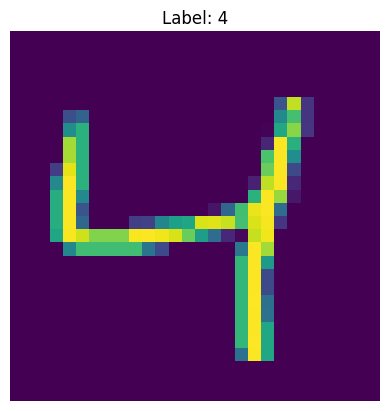

In [ ]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [ ]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [ ]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim,hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3 (out)

        # Linear function 4
        out = self.fc4 (out)  # 마지막 출력층
        return out

In [ ]:
# ANN 객체 생성
input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [ ]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.09249193221330643  Accuracy: 96.12765502929688 %
Iteration: 1000  Loss: 0.1978185772895813  Accuracy: 96.96439361572266 %
Iteration: 1500  Loss: 0.16690905392169952  Accuracy: 97.37303161621094 %
Iteration: 2000  Loss: 0.05726728215813637  Accuracy: 97.7232894897461 %
Iteration: 2500  Loss: 0.09861747175455093  Accuracy: 97.80113220214844 %
Iteration: 3000  Loss: 0.06152597814798355  Accuracy: 97.95680236816406 %
Iteration: 3500  Loss: 0.017371321097016335  Accuracy: 97.93733978271484 %
Iteration: 4000  Loss: 0.08139503747224808  Accuracy: 98.07355499267578 %
Iteration: 4500  Loss: 0.025097737088799477  Accuracy: 98.26814270019531 %


#### **ANN 학습 결과**

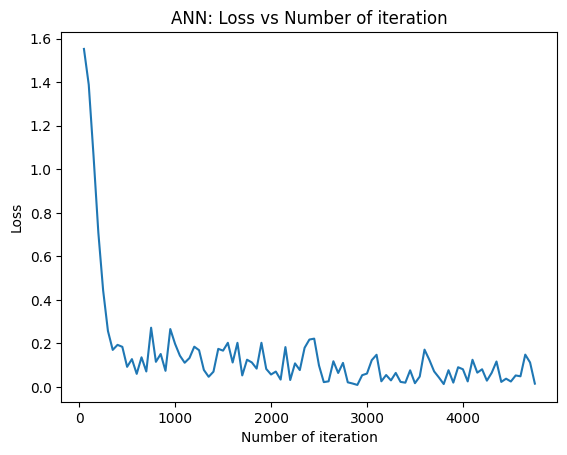

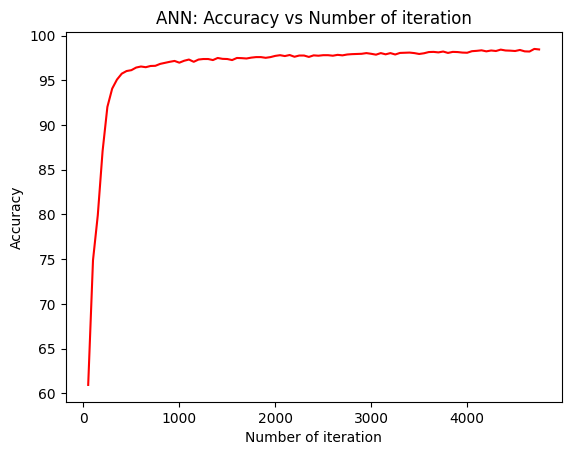

In [ ]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
- Loss 그래프: 반복이 진행될수록 손실이 급격히 감소한 뒤 작은 범위에서 진동하며 수렴
- Accuracy 그래프: 반복이 진행될수록 정확도가 빠르게 상승한 후 약 97~98% 수준에서 완만하게 증가하며 모델이 높은 성능에 도달


#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [ ]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import defaultdict

input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dims = [50, 80, 100, 120, 150, 180, 200]
output_dim = 5  # 출력 클래스 개수 (0~4)
hidden_dims_list = {}

for hidden_dim in hidden_dims:
  model = ANNModel(input_dim,hidden_dim,output_dim)
  # 손실 함수 설정
  loss_ftn = nn.CrossEntropyLoss()

  learning_rate = 0.02
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

  # 학습을 모니터링하기 위한 변수들
  count = 0  # 반복 횟수
  loss_list = []  # Loss 저장 리스트
  iteration_list = []  # Iteration 저장 리스트
  accuracy_list = []  # 정확도 저장 리스트

  # 전체 학습
  for epoch in range(3):

      # 배치 단위 학습
      for i, (images, labels) in enumerate(train_loader):

          # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
          train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
          labels = labels  # 텐서 형태 유지

          # 옵티마이저의 기울기 초기화
          optimizer.zero_grad()

          # Forward
          # 모델을 이용해 예측값(outputs) 계산
          outputs = model(train)

          # 손실 계산
          # cross entropy loss를 사용해 예측값과 실제값 비교
          loss = loss_ftn(outputs, labels)

          # Backward propagation - 손실에 대한 기울기 계산
          loss.backward()

          # 가중치 업데이트
          optimizer.step()

          count += 1  # 반복 횟수 증가

          if count % 50 == 0:
              # 정확도 계산을 위한 변수 초기화
              correct = 0
              total = 0


              # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
              for images, labels in test_loader:

                  test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                  # Forward
                  # 예측값 계산
                  outputs = model(test)

                  # 예측값 중 가장 높은 값을 선택
                  predicted = torch.max(outputs.data, 1)[1]

                  # 총 샘플 개수
                  total += len(labels)

                  # 올바르게 예측한 개수
                  correct += (predicted == labels).sum()

              # 정확도 계산
              accuracy = 100 * correct / float(total)

              # 손실 및 정확도 저장
              loss_list.append(loss.item())
              iteration_list.append(count)
              accuracy_list.append(accuracy)

          if count % 500 == 0:
              # 손실 및 정확도 출력
              print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))
  hidden_dims_list[hidden_dim] = (loss_list,accuracy_list)


Iteration: 500  Loss: 0.2304445207118988  Accuracy: 95.54387664794922 %
Iteration: 1000  Loss: 0.09789316356182098  Accuracy: 97.1978988647461 %
Iteration: 500  Loss: 0.1209489181637764  Accuracy: 96.14710998535156 %
Iteration: 1000  Loss: 0.2606065273284912  Accuracy: 97.23681640625 %
Iteration: 500  Loss: 0.18034200370311737  Accuracy: 96.04981231689453 %
Iteration: 1000  Loss: 0.13873475790023804  Accuracy: 97.17843627929688 %
Iteration: 500  Loss: 0.12055796384811401  Accuracy: 95.79684448242188 %
Iteration: 1000  Loss: 0.16533693671226501  Accuracy: 97.08114624023438 %
Iteration: 500  Loss: 0.14811480045318604  Accuracy: 96.3222427368164 %
Iteration: 1000  Loss: 0.052454929798841476  Accuracy: 97.21735382080078 %
Iteration: 500  Loss: 0.14183245599269867  Accuracy: 96.10819244384766 %
Iteration: 1000  Loss: 0.10194899141788483  Accuracy: 97.1978988647461 %
Iteration: 500  Loss: 0.1658063381910324  Accuracy: 96.22494506835938 %
Iteration: 1000  Loss: 0.16174012422561646  Accuracy: 

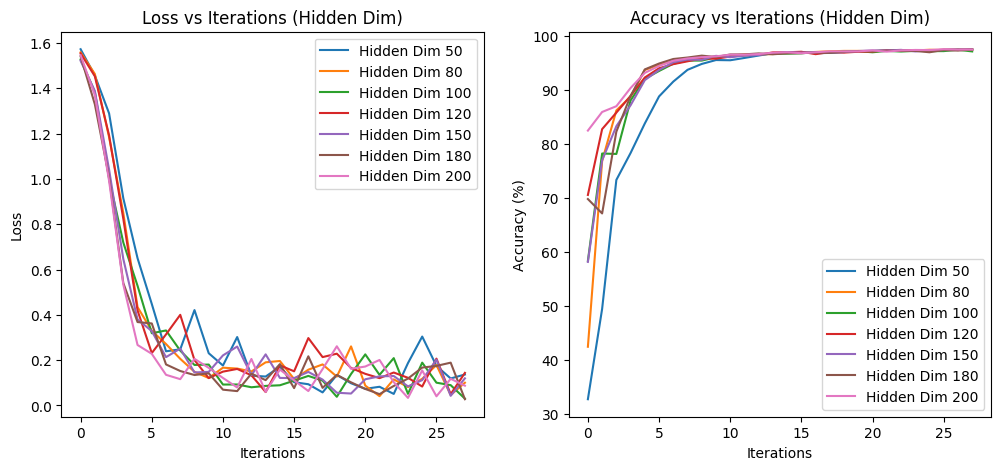

In [ ]:
# 실험 1 모델 학습 결과 시각화

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss 그래프
plt.subplot(1,2,1)
for h in hidden_dims_list:
    loss_list, acc_list = hidden_dims_list[h]
    plt.plot(range(len(loss_list)), loss_list, label=f'Hidden Dim {h}')
plt.title('Loss vs Iterations (Hidden Dim)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프
plt.subplot(1,2,2)
for h in hidden_dims_list:
    loss_list, acc_list = hidden_dims_list[h]
    plt.plot(range(len(acc_list)), acc_list, label=f'Hidden Dim {h}')
plt.title('Accuracy vs Iterations (Hidden Dim)')
plt.xlabel('Iterations')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()


**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- 일정 수준 이상에서는 손실과 정확도에는 큰 차이를 보이지 않는다.

In [ ]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import defaultdict

input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dims = 150
output_dim = 5  # 출력 클래스 개수 (0~4)
model = ANNModel(input_dim,hidden_dim,output_dim)
loss_ftn = nn.CrossEntropyLoss()
learning_rates = [0.1, 0.05, 0.025, 0.0125, 0.006]
learning_rates_list = {}

for learning_rate in learning_rates:

  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

  # 학습을 모니터링하기 위한 변수들
  count = 0  # 반복 횟수
  loss_list = []  # Loss 저장 리스트
  iteration_list = []  # Iteration 저장 리스트
  accuracy_list = []  # 정확도 저장 리스트

  # 전체 학습
  for epoch in range(3):

      # 배치 단위 학습
      for i, (images, labels) in enumerate(train_loader):

          # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
          train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
          labels = labels  # 텐서 형태 유지

          # 옵티마이저의 기울기 초기화
          optimizer.zero_grad()

          # Forward
          # 모델을 이용해 예측값(outputs) 계산
          outputs = model(train)

          # 손실 계산
          # cross entropy loss를 사용해 예측값과 실제값 비교
          loss = loss_ftn(outputs, labels)

          # Backward propagation - 손실에 대한 기울기 계산
          loss.backward()

          # 가중치 업데이트
          optimizer.step()

          count += 1  # 반복 횟수 증가

          if count % 50 == 0:
              # 정확도 계산을 위한 변수 초기화
              correct = 0
              total = 0


              # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
              for images, labels in test_loader:

                  test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                  # Forward
                  # 예측값 계산
                  outputs = model(test)

                  # 예측값 중 가장 높은 값을 선택
                  predicted = torch.max(outputs.data, 1)[1]

                  # 총 샘플 개수
                  total += len(labels)

                  # 올바르게 예측한 개수
                  correct += (predicted == labels).sum()

              # 정확도 계산
              accuracy = 100 * correct / float(total)

              # 손실 및 정확도 저장
              loss_list.append(loss.item())
              iteration_list.append(count)
              accuracy_list.append(accuracy)

          if count % 500 == 0:
              # 손실 및 정확도 출력
              print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))
  learning_rates_list[learning_rate] = (loss_list,accuracy_list)


Iteration: 500  Loss: 0.03697560355067253  Accuracy: 97.87896728515625 %
Iteration: 1000  Loss: 0.04092377424240112  Accuracy: 98.50165557861328 %
Iteration: 500  Loss: 0.004483452532440424  Accuracy: 99.02704620361328 %
Iteration: 1000  Loss: 0.0063929129391908646  Accuracy: 99.16326141357422 %
Iteration: 500  Loss: 0.012896417640149593  Accuracy: 99.18272399902344 %
Iteration: 1000  Loss: 0.00555557943880558  Accuracy: 99.28001403808594 %
Iteration: 500  Loss: 0.008438109420239925  Accuracy: 99.26055908203125 %
Iteration: 1000  Loss: 0.005439104977995157  Accuracy: 99.28001403808594 %
Iteration: 500  Loss: 0.00566651439294219  Accuracy: 99.20217895507812 %
Iteration: 1000  Loss: 0.002507338998839259  Accuracy: 99.28001403808594 %


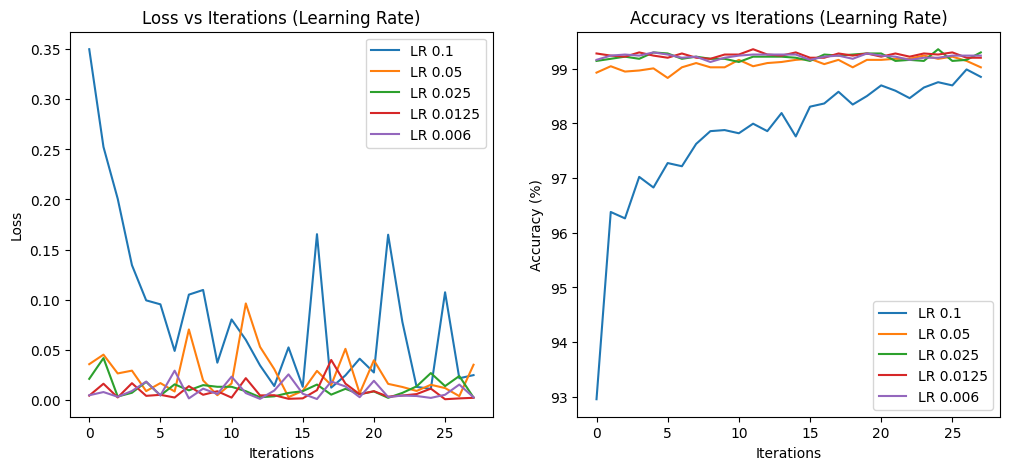

In [ ]:
# 실험 2 모델 학습 결과 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss 그래프
plt.subplot(1,2,1)
for lr in learning_rates:
    loss_list, acc_list = learning_rates_list[lr]
    plt.plot(range(len(loss_list)), loss_list, label=f'LR {lr}')
plt.title('Loss vs Iterations (Learning Rate)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프
plt.subplot(1,2,2)
for lr in learning_rates:
    loss_list, acc_list = learning_rates_list[lr]
    plt.plot(range(len(acc_list)), acc_list, label=f'LR {lr}')
plt.title('Accuracy vs Iterations (Learning Rate)')
plt.xlabel('Iterations')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()


**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- Loss: 학습률이 크면 빠르지만 불안정하고, 적절히 작으면 안정적이나 너무 작으면 느리다.
- Accuracy: 적절한 학습률에서 가장 안정적이고 높은 정확도를 달성한다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU() # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정


        # Fully Connected Layer
        self.fc1 = nn.Linear(32*4*4, 10) # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [ ]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.001)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [ ]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 1.9001653361171174
Epoch 2, Loss: 1.2287827497484292
Epoch 3, Loss: 0.5801777297121498
Epoch 4, Loss: 0.3018765126924674
Epoch 5, Loss: 0.22484000353823128
Epoch 6, Loss: 0.1911711771360021
Epoch 7, Loss: 0.17329880025914418
Epoch 8, Loss: 0.16157187000772524
Epoch 9, Loss: 0.15384068520883554
Epoch 10, Loss: 0.14691961896148878
Epoch 11, Loss: 0.14174166545349645
Epoch 12, Loss: 0.13745964870696775
Epoch 13, Loss: 0.1334820588455693
Epoch 14, Loss: 0.13001149648407742
Epoch 15, Loss: 0.1265960076127769
Epoch 16, Loss: 0.12379546032242461
Epoch 17, Loss: 0.12079461956385033
Epoch 18, Loss: 0.11829255238157893
Epoch 19, Loss: 0.11602976089557303
Epoch 20, Loss: 0.11340344437672163


#### **CNN 학습 결과**

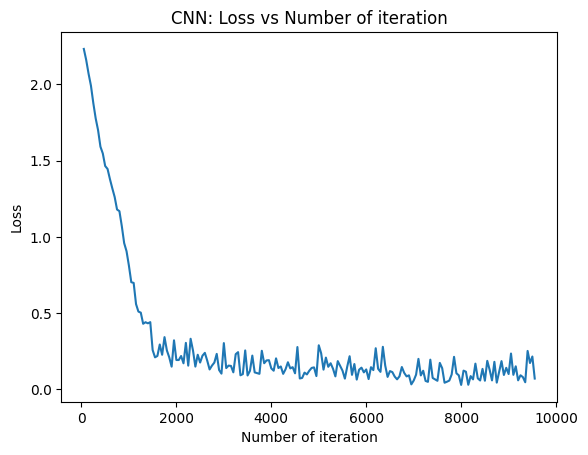

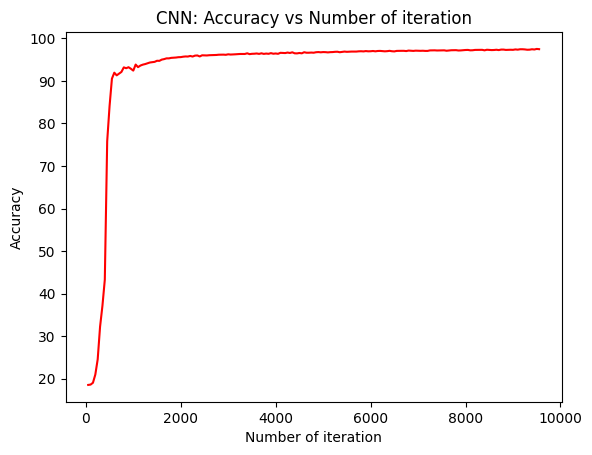

In [ ]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
MNIST 데이터셋에서 ANN과 CNN을 비교하면, ANN은 입력 이미지를 1차원으로 변환해 모든 노드가 서로 연결된 구조로 학습하며 손실이 빠르게 감소해 약 0.1 수준에서 수렴하고 정확도는 약 98%에 도달한다. 반면 CNN은 이미지의 2차원 구조를 유지한 채 합성곱층과 풀링층을 통해 특징을 추출하고 파라미터를 효율적으로 사용하며, 손실은 거의 0에 가깝게 줄어들고 정확도는 약 95% 수준에 수렴한다.